In [1]:
#More or less general imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import time

#Imports for Creating WebSky Maps 
import h5py
import healpy as hp
from pixell import enmap,utils, reproject, bunch, curvedsky, enplot

from scipy.interpolate import *
from astropy.cosmology import Planck15 as cosmo

#Unit conversion
from astropy import units as u
from stamping_utils import make_mask, make_stamp

#import ipyparallel as ipp
#from mpi4py import MPI
from colossus.cosmology import cosmology
from colossus.halo import mass_so, mass_defs, mass_adv
cosmology.setCosmology('planck18')
%load_ext autoreload
%autoreload 2

#Access to WebSky data
path = "/mnt/welch/USERS/cwhitaker/maps/websky/"
#path = "/scratch/jorlo/websky/"

%matplotlib inline

In [2]:
def make_halo_params():
    # Cosmology Constants
    omegab = 0.049
    omegac = 0.261
    omegam = omegab + omegac
    h      = 0.68
    ns     = 0.965
    sigma8 = 0.81
    c = 3e5
    
    H0 = 100*h
    nz = 100000
    z1 = 0.0
    z2 = 6.0
    za = np.linspace(z1,z2,nz)
    dz = za[1]-za[0]
    
    H      = lambda z: H0*np.sqrt(omegam*(1+z)**3+1-omegam)
    dchidz = lambda z: c/H(z)
    
    chia = np.cumsum(dchidz(za))*dz
    
    zofchi = interp1d(chia,za)

    cluster_catalog=open(path + 'halos.pksc')
    N = np.fromfile(cluster_catalog,count=3,dtype=np.int32)[0]
    # only take first five entries for testing (there are ~8e8 halos total...)
    # comment the following line to read in all halos
    #N = 10
    catalog=np.fromfile(cluster_catalog,count=int(N)*10,dtype=np.float32)
    catalog=np.reshape(catalog,(N,10))
    x  = catalog[:,0];  y = catalog[:,1];  z = catalog[:,2] # Mpc (comoving)
    vx = catalog[:,3]; vy = catalog[:,4]; vz = catalog[:,5] # km/sec
    R  = catalog[:,6] # Mpc

    # Constants
    rho       = 2.775e11*omegam*h**2       # Msun/Mpc^3
    M         = 4*np.pi/3.*rho*R**3        # this is M200m (mean density 200 times mean) in Msun
    chi       = np.sqrt(x**2+y**2+z**2)    # Mpc
    redshift  = zofchi(chi)
    theta,phi = hp.vec2ang(np.column_stack((x,y,z))) # in (not with utils.degree) radians
    ra        = phi
    dec       = np.pi/2. - theta

    return M, redshift, dec, ra, R, chi, rho, h

M, redshift, dec, ra, R, chi, rho, h = make_halo_params()

In [3]:
#Less bright / massive clusters = 3.0e14
z_cut = 0.05
M_cut = 2.0e14
cluster_flags = np.where((redshift > z_cut) & (M > M_cut))[0]
#Limit on parameters of clusters
M            = M[cluster_flags]
redshift     = redshift[cluster_flags]
cluster_decs = dec[cluster_flags] * 180/np.pi
cluster_ras  = ra[cluster_flags] * 180/np.pi
r            = R[cluster_flags]
chi          = chi[cluster_flags]

In [4]:
# Colossus functions takes Msun/h and outputs Msun/h and kpc/h
M_h = M / h
M200c_h = np.empty(len(M_h))
M500c_h = np.empty(len(M_h))
R200c_h = np.empty(len(M_h))
R500c_h = np.empty(len(M_h))
c200c   = np.empty(len(M_h))
c500c   = np.empty(len(M_h))

# Changing new definitions and appending them to a new array
for i in range(len(M_h)):
    M200c_h[i], R200c_h[i], c200c[i] = mass_defs.changeMassDefinition(
        M_h[i], 7.0, redshift[i], '200m', '200c')
    
    M500c_h[i], R500c_h[i], c500c[i] = mass_defs.changeMassDefinition(
        M_h[i], 7.0, redshift[i], '200m', '500c')

#R200m = ((3.0 * M) / (4.0 * np.pi * 200.0 * rho * (1.0 + redshift)**3 ))**(1/3)
M200c = M200c_h * h
M500c = M500c_h * h
R200c = R200c_h * h / 1000 #Mpc
R500c = R500c_h * h / 1000

In [5]:
# With z > 0.05 & M > 2.0e14 there's 246163 clusters remaining
d_A = cosmo.angular_diameter_distance(redshift).value
d_C = cosmo.comoving_distance(redshift).value
arc_size_200c = (2 * R200c / d_C) * (60 / utils.degree)
arc_size_500c = (2 * R500c / d_C) * (60 / utils.degree)
#arc_size_m = (R200m / d_A) * (60 / utils.degree)

print(arc_size_200c)
print(arc_size_500c)
#print(arc_size_m)

[10.43608389 19.43959909  7.94677655 ...  3.36821174  1.54745939
  0.89416543]
[ 6.90418871 12.80293935  5.26954897 ...  2.23175911  1.03254429
  0.59900405]


### Masks and Stamps

Code for masks and stamps. Below this plot function is original code that looks at the stamp and mask separately but I figured looking at more than one at a time would give a little more insight if the masks actually cover the stamp clusters.

In [8]:
def plot_stamps_and_masks_top(arc_sizes, n:int, seed=None, save=False):
    """Plotting random stamps with their respective mask outlines on top."""
    freqs = ["090", "150", "220"]
    # setup plot
    # fig, ax = plt.figure(figsize=(5, 5))
    plt.figure(figsize=(10, 5))
    
    if seed:
        seed = np.random.seed(seed)
    
    # make the stamps and mask
    for k in range(n):
        # ones to share: 34, 59, 30, 26, 1270,  if 2 * R is fine, 10354 is odd
        i = np.random.randint(0, len(cluster_ras))
        print(i)
        
        # boxes 
        dr = 5*arc_size_200c[i]*u.arcmin
        #dr = 21.578643339329634*u.arcmin
        offset_ra  = -1 * u.arcmin
        offset_dec = -1 * u.arcmin
    
        ra_cent  = cluster_ras[i]*u.deg + offset_ra
        dec_cent = cluster_decs[i]*u.deg + offset_dec
    
        ra_min, ra_max   = ra_cent - dr, ra_cent + dr
        dec_min, dec_max = dec_cent - dr, dec_cent + dr
        box = np.array([[dec_min.value, ra_min.value], [dec_max.value, ra_max.value]]) * utils.degree

        # stamps and masks
        stamp, cur_wcs = make_stamp(path + '/websky_f*_map.fits', box, freqs, normalize = False, reproj=True)
        mask = make_mask(stamp, cluster_ras, cluster_decs, box, cur_wcs, arc_sizes)

        # create subplot
        plt.subplot(1, n, k+1)

        # plot stamp
        plt.imshow(stamp[0])

        # overlay mask
        #masked = np.ma.masked_where(mask == 0, mask)
        plt.contour(mask.astype(float), levels = [0.5], colors="red", linewidths=1)

        #y, x = np.where(mask > 0)
        #ax.scatter(x.mean(), y.mean(), c="cyan", marker="x", s=10)
        #ax.imshow(masked, cmap='viridis', alpha=0.4)
        #ax.imshow(mask)
        plt.axis(False)
        
    plt.tight_layout()
    if save:
        plt.savefig(f"Cluster[{i}]_arc_size_200c_mask.png")

90896
227594
7686


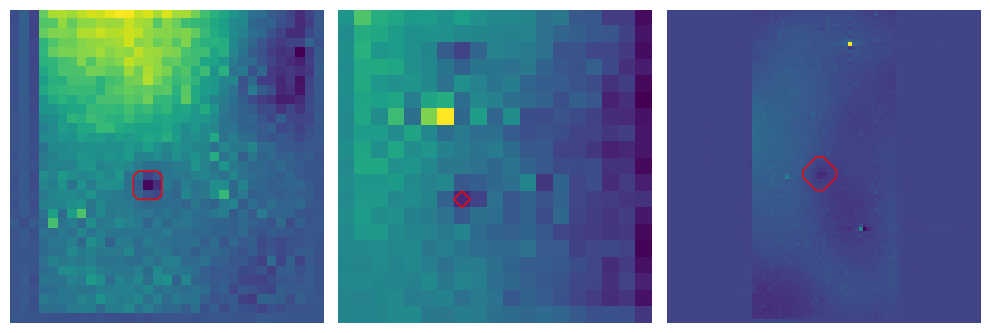

In [9]:
plot_stamps_and_masks_top(arc_sizes=arc_size_200c, n=3, seed=False)

In [10]:
#comm = MPI.COMM_WORLD
#myrank = comm.Get_rank()
#nproc = comm.Get_size()
freqs = ["090", "150", "220"]

i = 7686
print(f"Arc size of cluster{[i]} at redshift = {round(redshift[i], 2)} is {round(arc_size_500c[i], 2)} arcmin")

dr = 5*arc_size_200c[i]*u.arcmin
#dr  = 20*u.arcmin
#print(f"dr is {round(dr, 2)}")

#offset_ra, offset_dec = np.random.rand()*5*u.arcmin, np.random.rand()*5*u.arcmin
offset_ra, offset_dec = -1*u.arcmin, -1*u.arcmin
ra_cent = cluster_ras[i]*u.deg+offset_ra
dec_cent = cluster_decs[i]*u.deg+offset_dec
ra_min, ra_max = ra_cent - dr, ra_cent + dr
dec_min, dec_max = dec_cent - dr, dec_cent + dr
box = np.array([[dec_min.value, ra_min.value],[dec_max.value, ra_max.value]]) * utils.degree

# Stamps and Masks
stamp, cur_wcs = make_stamp(path + '/websky_f*_map.fits', box, freqs, normalize = False, reproj=True)
mask = make_mask(stamp, cluster_ras, cluster_decs, box, cur_wcs, arc_size_200c)

Arc size of cluster[7686] at redshift = 0.37 is 2.81 arcmin


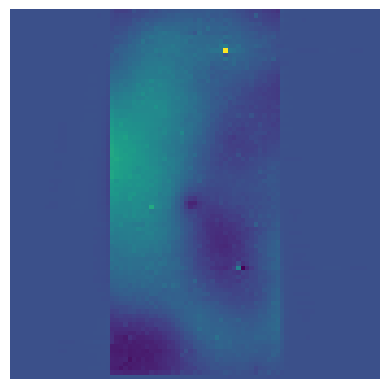

In [17]:
plt.imshow(stamp[1])
plt.axis(False);
#plt.savefig('Example_cluster[198041]_arc_size_200c_stamp')

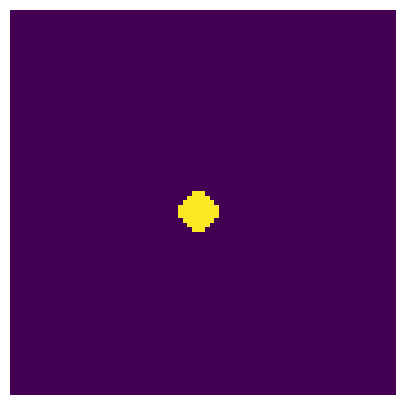

In [18]:
#lims= 300
plt.figure(figsize=(10, 5))
plt.imshow(mask)#, vmin=-lims, vmax=lims)
plt.axis(False);
#plt.savefig('2_cluster[4]_10*arc_size_500c_mask')

### Creating Stamps and Mask (All of this is for later)

For later

Creating tiles and corresponding stamps centered around celestial coordinates. In this code 313 boxes are created.

### Individual Freq Cuts